# 1. Setup și Instalări
Ne asigurăm că avem toate bibliotecile necesare instalate, inclusiv `timm` pentru Inception-ResNet-v2.

In [2]:
# Rulează asta o singură dată
# !pip install timm pandas matplotlib seaborn scikit-learn tqdm

# 2. Explorarea Datelor (EDA)
Verificăm dacă DataLoader-ul nostru încarcă corect imaginile și dacă augmentările (rotații, culori) arată bine pe setul de antrenare.

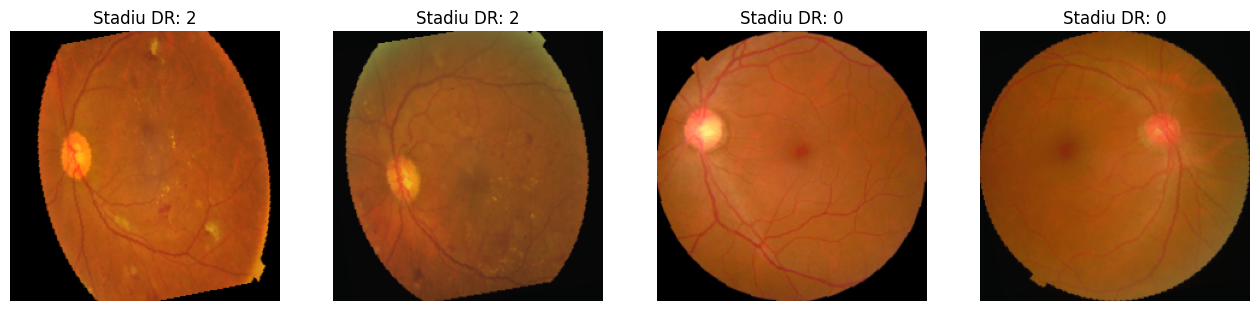

In [3]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from my_dataset import DRDataset

# Schimbă 'aptos' cu ce dataset vrei să vizualizezi
dataset_eda = DRDataset(root_dir='../../', dataset_name='aptos', split='train', image_size=224)
loader_eda = DataLoader(dataset_eda, batch_size=4, shuffle=True)

# Luăm un batch
batch = next(iter(loader_eda))
imagini = batch[0]
etichete = batch[1]

# Afișare
plt.figure(figsize=(16, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    # Convertim din Tensor PyTorch (C, H, W) in Numpy (H, W, C)
    img_viz = imagini[i].permute(1, 2, 0).numpy()
    
    # De-normalizare pentru afișare corectă (valori între 0 și 1)
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    img_viz = std * img_viz + mean
    img_viz = img_viz.clip(0, 1)
    
    plt.imshow(img_viz)
    plt.title(f"Stadiu DR: {etichete[i].item()}")
    plt.axis('off')
plt.show()

## Partea 1: Evaluarea Arhitecturilor (8 Experimente)
Păstrăm dataset-ul (APTOS), loss-ul (CE) și learning rate-ul (0.0001) constante. Variem doar arhitectura rețelei pentru a vedea care extrage cele mai bune caracteristici.

*Notă: Modelele Inception necesită rezoluție 299x299. Folosim `num_workers=0` pentru stabilitate în Notebook pe Windows.*

In [4]:
# 1. Baseline (ResNet-50)
%run train.py --dataset aptos --model resnet50 --loss ce --lr 0.0001 --epochs 50 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: resnet50 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/50] | Train Loss: 1.3636 (Acc: 49.6%) | Test Loss: 1.2460 (Acc: 58.7%) | Timp: 1m 10s  --> Model salvat! (Loss nou record: 1.2460)
Epoca [2/50] | Train Loss: 1.2001 (Acc: 58.1%) | Test Loss: 1.1369 (Acc: 68.6%) | Timp: 1m 7s  --> Model salvat! (Loss nou record: 1.1369)
Epoca [3/50] | Train Loss: 1.1100 (Acc: 63.2%) | Test Loss: 1.0787 (Acc: 72.4%) | Timp: 1m 5s  --> Model salvat! (Loss nou record: 1.0787)
Epoca [4/50] | Train Loss: 1.0585 (Acc: 67.3%) | Test Loss: 1.0227 (Acc: 73.5%) | Timp: 1m 4s  --> Model salvat! (Loss nou record: 1.0227)
Epoca [5/50] | Train Loss: 1.0049 (Acc: 67.2%) | Test Loss: 0.9481 (Acc: 71.9%) | Timp: 1m 4s  --> Model salvat! (Loss nou record: 0.9481)
Epoca [6/50] | Train Loss: 0.9751 (Acc: 68.9%) | Test Loss: 0.9407 (Acc: 72.4%) | Timp: 1m 4s  --> Model salvat! (Loss nou record: 0.9407)
Epoca [7/50] | Train Loss: 

In [5]:
# 2. ResNet-34 (Versiunea mai ușoară)
%run train.py --dataset aptos --model resnet34 --loss ce --lr 0.0001 --epochs 50 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: resnet34 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/50] | Train Loss: 1.4253 (Acc: 46.2%) | Test Loss: 1.1143 (Acc: 66.1%) | Timp: 1m 0s  --> Model salvat! (Loss nou record: 1.1143)
Epoca [2/50] | Train Loss: 1.2536 (Acc: 54.4%) | Test Loss: 0.9963 (Acc: 70.2%) | Timp: 0m 54s  --> Model salvat! (Loss nou record: 0.9963)
Epoca [3/50] | Train Loss: 1.1518 (Acc: 60.0%) | Test Loss: 0.9338 (Acc: 70.8%) | Timp: 1m 2s  --> Model salvat! (Loss nou record: 0.9338)
Epoca [4/50] | Train Loss: 1.1017 (Acc: 61.9%) | Test Loss: 0.8836 (Acc: 71.3%) | Timp: 0m 52s  --> Model salvat! (Loss nou record: 0.8836)
Epoca [5/50] | Train Loss: 1.0399 (Acc: 63.9%) | Test Loss: 0.8442 (Acc: 71.9%) | Timp: 1m 2s  --> Model salvat! (Loss nou record: 0.8442)
Epoca [6/50] | Train Loss: 1.0048 (Acc: 64.2%) | Test Loss: 0.8214 (Acc: 73.2%) | Timp: 0m 56s  --> Model salvat! (Loss nou record: 0.8214)
Epoca [7/50] | Train Loss

In [6]:
# 3. EfficientNet-B0
%run train.py --dataset aptos --model efficientnet_b0 --loss ce --lr 0.0001 --epochs 50 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: efficientnet_b0 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/50] | Train Loss: 0.9236 (Acc: 66.8%) | Test Loss: 0.5741 (Acc: 78.1%) | Timp: 1m 4s  --> Model salvat! (Loss nou record: 0.5741)
Epoca [2/50] | Train Loss: 0.6031 (Acc: 78.0%) | Test Loss: 0.5011 (Acc: 81.1%) | Timp: 1m 3s  --> Model salvat! (Loss nou record: 0.5011)
Epoca [3/50] | Train Loss: 0.5105 (Acc: 80.9%) | Test Loss: 0.4665 (Acc: 82.8%) | Timp: 1m 4s  --> Model salvat! (Loss nou record: 0.4665)
Epoca [4/50] | Train Loss: 0.4521 (Acc: 83.3%) | Test Loss: 0.4499 (Acc: 83.1%) | Timp: 1m 3s  --> Model salvat! (Loss nou record: 0.4499)
Epoca [5/50] | Train Loss: 0.4042 (Acc: 84.7%) | Test Loss: 0.4661 (Acc: 83.6%) | Timp: 0m 59s
Epoca [6/50] | Train Loss: 0.3822 (Acc: 85.5%) | Test Loss: 0.4360 (Acc: 84.4%) | Timp: 1m 3s  --> Model salvat! (Loss nou record: 0.4360)
Epoca [7/50] | Train Loss: 0.3470 (Acc: 87.7%) | Test Loss: 0.477

In [7]:
# 4. EfficientNet-B3
%run train.py --dataset aptos --model efficientnet_b3 --loss ce --lr 0.0001 --epochs 50 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: efficientnet_b3 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/50] | Train Loss: 0.9800 (Acc: 66.5%) | Test Loss: 0.6227 (Acc: 76.8%) | Timp: 1m 5s  --> Model salvat! (Loss nou record: 0.6227)
Epoca [2/50] | Train Loss: 0.6267 (Acc: 76.4%) | Test Loss: 0.5239 (Acc: 78.4%) | Timp: 1m 5s  --> Model salvat! (Loss nou record: 0.5239)
Epoca [3/50] | Train Loss: 0.5363 (Acc: 80.1%) | Test Loss: 0.4861 (Acc: 81.1%) | Timp: 1m 4s  --> Model salvat! (Loss nou record: 0.4861)
Epoca [4/50] | Train Loss: 0.4529 (Acc: 83.3%) | Test Loss: 0.4456 (Acc: 83.9%) | Timp: 1m 4s  --> Model salvat! (Loss nou record: 0.4456)
Epoca [5/50] | Train Loss: 0.4148 (Acc: 84.2%) | Test Loss: 0.5351 (Acc: 82.5%) | Timp: 1m 5s
Epoca [6/50] | Train Loss: 0.3807 (Acc: 85.2%) | Test Loss: 0.4345 (Acc: 84.7%) | Timp: 1m 5s  --> Model salvat! (Loss nou record: 0.4345)
Epoca [7/50] | Train Loss: 0.3506 (Acc: 86.6%) | Test Loss: 0.4931

In [8]:
# 5. DenseNet-121
%run train.py --dataset aptos --model densenet121 --loss ce --lr 0.0001 --epochs 50 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: densenet121 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/50] | Train Loss: 0.6793 (Acc: 75.4%) | Test Loss: 0.4947 (Acc: 81.1%) | Timp: 1m 5s  --> Model salvat! (Loss nou record: 0.4947)
Epoca [2/50] | Train Loss: 0.4806 (Acc: 82.5%) | Test Loss: 0.4215 (Acc: 84.2%) | Timp: 1m 6s  --> Model salvat! (Loss nou record: 0.4215)
Epoca [3/50] | Train Loss: 0.4258 (Acc: 84.2%) | Test Loss: 0.4152 (Acc: 83.6%) | Timp: 1m 4s  --> Model salvat! (Loss nou record: 0.4152)
Epoca [4/50] | Train Loss: 0.3812 (Acc: 85.9%) | Test Loss: 0.4288 (Acc: 85.2%) | Timp: 1m 4s
Epoca [5/50] | Train Loss: 0.3484 (Acc: 87.1%) | Test Loss: 0.4405 (Acc: 83.9%) | Timp: 1m 5s
Epoca [6/50] | Train Loss: 0.3262 (Acc: 87.9%) | Test Loss: 0.4439 (Acc: 82.5%) | Timp: 1m 6s
Epoca [7/50] | Train Loss: 0.2786 (Acc: 89.0%) | Test Loss: 0.4736 (Acc: 83.6%) | Timp: 1m 5s
Epoca [8/50] | Train Loss: 0.2651 (Acc: 90.1%) | Test Loss: 0.5529

In [9]:
# 6. VGG-16 (Model clasic liniar - reducem batch-ul pentru a evita erori de memorie)
%run train.py --dataset aptos --model vgg16 --loss ce --lr 0.0001 --epochs 50 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: vgg16 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/50] | Train Loss: 0.7739 (Acc: 71.9%) | Test Loss: 0.7111 (Acc: 73.0%) | Timp: 9m 52s  --> Model salvat! (Loss nou record: 0.7111)
Epoca [2/50] | Train Loss: 0.5967 (Acc: 76.5%) | Test Loss: 0.4895 (Acc: 81.4%) | Timp: 9m 51s  --> Model salvat! (Loss nou record: 0.4895)
Epoca [3/50] | Train Loss: 0.5321 (Acc: 79.9%) | Test Loss: 0.5187 (Acc: 80.9%) | Timp: 9m 54s
Epoca [4/50] | Train Loss: 0.5147 (Acc: 80.8%) | Test Loss: 0.4687 (Acc: 83.6%) | Timp: 9m 49s  --> Model salvat! (Loss nou record: 0.4687)
Epoca [5/50] | Train Loss: 0.4671 (Acc: 82.1%) | Test Loss: 0.4659 (Acc: 84.2%) | Timp: 9m 47s  --> Model salvat! (Loss nou record: 0.4659)
Epoca [6/50] | Train Loss: 0.4640 (Acc: 82.3%) | Test Loss: 0.4664 (Acc: 82.2%) | Timp: 9m 47s
Epoca [7/50] | Train Loss: 0.4201 (Acc: 84.7%) | Test Loss: 0.4445 (Acc: 84.7%) | Timp: 9m 48s  --> Model salvat! (

In [10]:
# 7. Inception-v3 (Necesită rezoluție 299)
%run train.py --dataset aptos --model inception_v3 --loss ce --lr 0.0001 --img_size 299 --epochs 50 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: inception_v3 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/50] | Train Loss: 0.7299 (Acc: 73.8%) | Test Loss: 0.5018 (Acc: 80.6%) | Timp: 0m 52s  --> Model salvat! (Loss nou record: 0.5018)
Epoca [2/50] | Train Loss: 0.5129 (Acc: 80.4%) | Test Loss: 0.4567 (Acc: 82.2%) | Timp: 0m 51s  --> Model salvat! (Loss nou record: 0.4567)
Epoca [3/50] | Train Loss: 0.4368 (Acc: 83.4%) | Test Loss: 0.4762 (Acc: 83.9%) | Timp: 0m 54s
Epoca [4/50] | Train Loss: 0.3836 (Acc: 85.5%) | Test Loss: 0.5062 (Acc: 84.2%) | Timp: 0m 56s
Epoca [5/50] | Train Loss: 0.3399 (Acc: 87.8%) | Test Loss: 0.5016 (Acc: 82.2%) | Timp: 0m 53s
Epoca [6/50] | Train Loss: 0.3099 (Acc: 88.5%) | Test Loss: 0.5123 (Acc: 83.3%) | Timp: 0m 55s
Epoca [7/50] | Train Loss: 0.2552 (Acc: 90.2%) | Test Loss: 0.5256 (Acc: 84.2%) | Timp: 0m 55s
Epoca [8/50] | Train Loss: 0.2428 (Acc: 91.1%) | Test Loss: 0.4863 (Acc: 85.0%) | Timp: 0m 55s
Epoca [9

In [11]:
# 8. Inception-ResNet-v2 (Cel mai greu model, rezoluție 299)
%run train.py --dataset aptos --model incres_v2 --loss ce --lr 0.0001 --img_size 299 --epochs 50 --batch_size 32 --num_workers 4

🔥 Rulăm pe device: cuda | Model: incres_v2 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/50] | Train Loss: 0.6939 (Acc: 75.4%) | Test Loss: 0.5107 (Acc: 82.2%) | Timp: 2m 37s  --> Model salvat! (Loss nou record: 0.5107)
Epoca [2/50] | Train Loss: 0.4935 (Acc: 81.3%) | Test Loss: 0.4715 (Acc: 83.3%) | Timp: 2m 34s  --> Model salvat! (Loss nou record: 0.4715)
Epoca [3/50] | Train Loss: 0.4102 (Acc: 84.0%) | Test Loss: 0.5026 (Acc: 83.3%) | Timp: 2m 35s
Epoca [4/50] | Train Loss: 0.3389 (Acc: 88.3%) | Test Loss: 0.4541 (Acc: 83.9%) | Timp: 2m 35s  --> Model salvat! (Loss nou record: 0.4541)
Epoca [5/50] | Train Loss: 0.3013 (Acc: 89.1%) | Test Loss: 0.5145 (Acc: 84.7%) | Timp: 2m 35s
Epoca [6/50] | Train Loss: 0.2819 (Acc: 89.6%) | Test Loss: 0.4809 (Acc: 84.4%) | Timp: 2m 34s
Epoca [7/50] | Train Loss: 0.2412 (Acc: 91.1%) | Test Loss: 0.5579 (Acc: 80.1%) | Timp: 2m 35s
Epoca [8/50] | Train Loss: 0.1989 (Acc: 92.9%) | Test Loss: 0

## Partea 2: Evaluarea Capacității de Generalizare (4 Dataset-uri)
Păstrăm arhitectura (ResNet-50), loss-ul (CE) și LR-ul (0.0001) constante. Testăm cum se comportă același model pe baze de date cu distribuții, dimensiuni și calități diferite.
*(Experimentul pe APTOS a fost deja rulat în Partea 1, dar îl putem include pentru completitudine).*

In [12]:
# 1. APTOS (Baseline-ul deja testat)
# %run train.py --dataset aptos --model resnet50 --loss ce --lr 0.0001 --epochs 15 --num_workers 0

In [13]:
# 2. IDRiD (Set mic, imagini de înaltă calitate, dezechilibrat)
%run train.py --dataset idrid --model resnet50 --loss ce --lr 0.0001 --epochs 50 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: resnet50 | Dataset: idrid (Multi-Clasă)
Imagini train: 455 | Imagini test: 455

Începe antrenamentul...
Epoca [1/50] | Train Loss: 1.5980 (Acc: 24.4%) | Test Loss: 1.5359 (Acc: 36.3%) | Timp: 0m 24s  --> Model salvat! (Loss nou record: 1.5359)
Epoca [2/50] | Train Loss: 1.4951 (Acc: 36.9%) | Test Loss: 1.4732 (Acc: 39.3%) | Timp: 0m 29s  --> Model salvat! (Loss nou record: 1.4732)
Epoca [3/50] | Train Loss: 1.4643 (Acc: 42.6%) | Test Loss: 1.4420 (Acc: 41.1%) | Timp: 0m 37s  --> Model salvat! (Loss nou record: 1.4420)
Epoca [4/50] | Train Loss: 1.4280 (Acc: 42.6%) | Test Loss: 1.4104 (Acc: 41.1%) | Timp: 0m 27s  --> Model salvat! (Loss nou record: 1.4104)
Epoca [5/50] | Train Loss: 1.4314 (Acc: 45.1%) | Test Loss: 1.3916 (Acc: 43.3%) | Timp: 0m 23s  --> Model salvat! (Loss nou record: 1.3916)
Epoca [6/50] | Train Loss: 1.3899 (Acc: 43.7%) | Test Loss: 1.3751 (Acc: 44.6%) | Timp: 0m 22s  --> Model salvat! (Loss nou record: 1.3751)
Epoca [7/50] | Train Lo

In [14]:
# 3. Messidor-2 (Standardul de aur medical, grading strict)
%run train.py --dataset messidor2 --model resnet50 --loss ce --lr 0.0001 --epochs 50 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: resnet50 | Dataset: messidor2 (Multi-Clasă)
Imagini train: 1744 | Imagini test: 1744

Începe antrenamentul...
Epoca [1/50] | Train Loss: 1.3980 (Acc: 51.2%) | Test Loss: 1.2848 (Acc: 58.3%) | Timp: 0m 22s  --> Model salvat! (Loss nou record: 1.2848)
Epoca [2/50] | Train Loss: 1.2181 (Acc: 58.3%) | Test Loss: 1.1737 (Acc: 58.3%) | Timp: 0m 20s  --> Model salvat! (Loss nou record: 1.1737)
Epoca [3/50] | Train Loss: 1.1339 (Acc: 58.7%) | Test Loss: 1.1135 (Acc: 58.4%) | Timp: 0m 20s  --> Model salvat! (Loss nou record: 1.1135)
Epoca [4/50] | Train Loss: 1.1160 (Acc: 58.2%) | Test Loss: 1.0884 (Acc: 58.5%) | Timp: 0m 20s  --> Model salvat! (Loss nou record: 1.0884)
Epoca [5/50] | Train Loss: 1.0998 (Acc: 58.6%) | Test Loss: 1.0913 (Acc: 59.2%) | Timp: 0m 20s
Epoca [6/50] | Train Loss: 1.0832 (Acc: 59.4%) | Test Loss: 1.0577 (Acc: 59.4%) | Timp: 0m 20s  --> Model salvat! (Loss nou record: 1.0577)
Epoca [7/50] | Train Loss: 1.0886 (Acc: 60.4%) | Test Loss: 1.

In [15]:
# 4. Kaggle EyePACS (Set masiv, mult zgomot, reducem batch-ul)
%run train.py --dataset eyepacs --model resnet50 --loss ce --lr 0.0001 --epochs 15 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: resnet50 | Dataset: eyepacs (Multi-Clasă)
Imagini train: 35126 | Imagini test: 53576

Începe antrenamentul...
Epoca [1/15] | Train Loss: 0.9258 (Acc: 72.8%) | Test Loss: 0.8638 (Acc: 73.8%) | Timp: 4m 28s  --> Model salvat! (Loss nou record: 0.8638)
Epoca [2/15] | Train Loss: 0.8695 (Acc: 73.5%) | Test Loss: 0.8637 (Acc: 73.8%) | Timp: 4m 27s  --> Model salvat! (Loss nou record: 0.8637)
Epoca [3/15] | Train Loss: 0.8692 (Acc: 73.5%) | Test Loss: 0.8643 (Acc: 73.8%) | Timp: 4m 27s
Epoca [4/15] | Train Loss: 0.8696 (Acc: 73.5%) | Test Loss: 0.8638 (Acc: 73.8%) | Timp: 4m 28s
Epoca [5/15] | Train Loss: 0.8689 (Acc: 73.5%) | Test Loss: 0.8646 (Acc: 73.8%) | Timp: 4m 28s
Epoca [6/15] | Train Loss: 0.8691 (Acc: 73.5%) | Test Loss: 0.8641 (Acc: 73.8%) | Timp: 4m 27s
Epoca [7/15] | Train Loss: 0.8688 (Acc: 73.5%) | Test Loss: 0.8640 (Acc: 73.8%) | Timp: 4m 26s
Epoca [8/15] | Train Loss: 0.8694 (Acc: 73.5%) | Test Loss: 0.8638 (Acc: 73.8%) | Timp: 4m 27s
Epoca [

## Partea 3: Impactul Funcției de Pierdere (4 Loss-uri)
Păstrăm dataset-ul (APTOS), modelul (ResNet-50) și LR-ul (0.0001) constante. Variem modul în care modelul este penalizat pentru greșeli.

In [16]:
# 1. CrossEntropy (Baseline-ul deja testat)
%run train.py --dataset aptos --model resnet50 --loss ce --lr 0.0001 --epochs 50 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: resnet50 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/50] | Train Loss: 1.3651 (Acc: 48.7%) | Test Loss: 1.2175 (Acc: 56.3%) | Timp: 0m 47s  --> Model salvat! (Loss nou record: 1.2175)
Epoca [2/50] | Train Loss: 1.1880 (Acc: 57.5%) | Test Loss: 1.1187 (Acc: 69.4%) | Timp: 0m 50s  --> Model salvat! (Loss nou record: 1.1187)
Epoca [3/50] | Train Loss: 1.1079 (Acc: 64.4%) | Test Loss: 1.0368 (Acc: 69.7%) | Timp: 0m 51s  --> Model salvat! (Loss nou record: 1.0368)
Epoca [4/50] | Train Loss: 1.0461 (Acc: 65.9%) | Test Loss: 0.9983 (Acc: 71.6%) | Timp: 0m 49s  --> Model salvat! (Loss nou record: 0.9983)
Epoca [5/50] | Train Loss: 1.0030 (Acc: 67.2%) | Test Loss: 0.9510 (Acc: 73.2%) | Timp: 0m 51s  --> Model salvat! (Loss nou record: 0.9510)
Epoca [6/50] | Train Loss: 0.9674 (Acc: 68.9%) | Test Loss: 0.9264 (Acc: 71.9%) | Timp: 0m 48s  --> Model salvat! (Loss nou record: 0.9264)
Epoca [7/50] | Train L

In [17]:
# 2. Regresie Ordinală cu BCE (Ține cont de progresia bolii: 0 -> 1 -> 2 -> 3 -> 4)
%run train.py --dataset aptos --model resnet50 --loss bce_ordinal --lr 0.0001 --epochs 50 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: resnet50 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/50] | Train Loss: 0.5346 (Acc: 47.1%) | Test Loss: 0.4713 (Acc: 54.4%) | Timp: 1m 3s  --> Model salvat! (Loss nou record: 0.4713)
Epoca [2/50] | Train Loss: 0.4122 (Acc: 48.9%) | Test Loss: 0.4109 (Acc: 54.4%) | Timp: 1m 2s  --> Model salvat! (Loss nou record: 0.4109)
Epoca [3/50] | Train Loss: 0.3731 (Acc: 48.9%) | Test Loss: 0.3843 (Acc: 54.4%) | Timp: 1m 2s  --> Model salvat! (Loss nou record: 0.3843)
Epoca [4/50] | Train Loss: 0.3463 (Acc: 48.9%) | Test Loss: 0.3471 (Acc: 54.4%) | Timp: 1m 1s  --> Model salvat! (Loss nou record: 0.3471)
Epoca [5/50] | Train Loss: 0.3324 (Acc: 48.9%) | Test Loss: 0.3366 (Acc: 54.4%) | Timp: 1m 2s  --> Model salvat! (Loss nou record: 0.3366)
Epoca [6/50] | Train Loss: 0.3148 (Acc: 48.9%) | Test Loss: 0.3203 (Acc: 54.4%) | Timp: 1m 21s  --> Model salvat! (Loss nou record: 0.3203)
Epoca [7/50] | Train Loss: 

In [18]:
# 3. Focal Loss (Penalizează mai tare exemplele "grele")
%run train.py --dataset aptos --model resnet50 --loss focal_loss --lr 0.0001 --epochs 50 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: resnet50 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/50] | Train Loss: 0.8031 (Acc: 48.6%) | Test Loss: 0.7018 (Acc: 66.1%) | Timp: 1m 3s  --> Model salvat! (Loss nou record: 0.7018)
Epoca [2/50] | Train Loss: 0.6731 (Acc: 62.5%) | Test Loss: 0.6231 (Acc: 70.5%) | Timp: 1m 2s  --> Model salvat! (Loss nou record: 0.6231)
Epoca [3/50] | Train Loss: 0.6199 (Acc: 66.5%) | Test Loss: 0.5812 (Acc: 72.1%) | Timp: 1m 1s  --> Model salvat! (Loss nou record: 0.5812)
Epoca [4/50] | Train Loss: 0.5754 (Acc: 68.1%) | Test Loss: 0.5486 (Acc: 73.2%) | Timp: 0m 59s  --> Model salvat! (Loss nou record: 0.5486)
Epoca [5/50] | Train Loss: 0.5490 (Acc: 69.6%) | Test Loss: 0.5225 (Acc: 73.2%) | Timp: 1m 0s  --> Model salvat! (Loss nou record: 0.5225)
Epoca [6/50] | Train Loss: 0.5263 (Acc: 70.0%) | Test Loss: 0.5001 (Acc: 73.5%) | Timp: 1m 0s  --> Model salvat! (Loss nou record: 0.5001)
Epoca [7/50] | Train Loss: 

In [23]:
# 4. Weighted CrossEntropy (Ajută clasele minoritare - stadiile 3 și 4)
%run train.py --dataset aptos --model resnet50 --loss weighted_ce --lr 0.0001 --epochs 10 --batch_size 32 --num_workers 8 --use_weights

🔥 Rulăm pe device: cuda | Model: resnet50 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366
⚖️ Folosim Weighted CrossEntropy cu ponderile: [0.1, 0.8, 1.2, 2.5, 5.0]

Începe antrenamentul...
Epoca [1/10] | Train Loss: 1.4643 (Acc: 17.2%) | Test Loss: 1.3555 (Acc: 18.3%) | Timp: 0m 58s  --> Model salvat! (Loss nou record: 1.3555)
Epoca [2/10] | Train Loss: 1.3549 (Acc: 19.8%) | Test Loss: 1.3076 (Acc: 13.9%) | Timp: 0m 58s  --> Model salvat! (Loss nou record: 1.3076)
Epoca [3/10] | Train Loss: 1.3387 (Acc: 17.1%) | Test Loss: 1.2837 (Acc: 15.8%) | Timp: 0m 58s  --> Model salvat! (Loss nou record: 1.2837)
Epoca [4/10] | Train Loss: 1.3216 (Acc: 17.5%) | Test Loss: 1.2619 (Acc: 15.0%) | Timp: 0m 57s  --> Model salvat! (Loss nou record: 1.2619)
Epoca [5/10] | Train Loss: 1.3041 (Acc: 18.3%) | Test Loss: 1.2469 (Acc: 18.6%) | Timp: 0m 53s  --> Model salvat! (Loss nou record: 1.2469)
Epoca [6/10] | Train Loss: 1.2875 (Acc: 16.9%) | Test Loss: 1.2323 (Acc: 22.7%) | Timp: 0

## Partea 4: Sensibilitatea la Learning Rate (2 LR-uri)
Păstrăm dataset-ul (APTOS), modelul (ResNet-50) și Loss-ul (CE) constante. Verificăm dacă o viteză de învățare mai mare sau mai mică schimbă punctul de convergență.

In [20]:
# 1. Learning Rate = 0.0001 (Baseline-ul deja testat)
# %run train.py --dataset aptos --model resnet50 --loss ce --lr 0.0001 --epochs 15 --num_workers 0

In [21]:
# 2. Learning Rate = 0.001 (Învățare de 10 ori mai rapidă, risc mai mare de instabilitate)
%run train.py --dataset aptos --model resnet50 --loss ce --lr 0.001 --epochs 50 --batch_size 32 --num_workers 8

🔥 Rulăm pe device: cuda | Model: resnet50 | Dataset: aptos (Multi-Clasă)
Imagini train: 2930 | Imagini test: 366

Începe antrenamentul...
Epoca [1/50] | Train Loss: 1.0581 (Acc: 64.2%) | Test Loss: 0.8500 (Acc: 74.0%) | Timp: 0m 56s  --> Model salvat! (Loss nou record: 0.8500)
Epoca [2/50] | Train Loss: 0.8328 (Acc: 71.1%) | Test Loss: 0.7369 (Acc: 75.1%) | Timp: 0m 55s  --> Model salvat! (Loss nou record: 0.7369)
Epoca [3/50] | Train Loss: 0.7648 (Acc: 73.4%) | Test Loss: 0.7039 (Acc: 75.7%) | Timp: 0m 55s  --> Model salvat! (Loss nou record: 0.7039)
Epoca [4/50] | Train Loss: 0.7349 (Acc: 73.3%) | Test Loss: 0.6764 (Acc: 74.9%) | Timp: 0m 52s  --> Model salvat! (Loss nou record: 0.6764)
Epoca [5/50] | Train Loss: 0.7085 (Acc: 74.6%) | Test Loss: 0.6490 (Acc: 75.1%) | Timp: 0m 51s  --> Model salvat! (Loss nou record: 0.6490)
Epoca [6/50] | Train Loss: 0.6903 (Acc: 74.8%) | Test Loss: 0.6371 (Acc: 75.4%) | Timp: 0m 53s  --> Model salvat! (Loss nou record: 0.6371)
Epoca [7/50] | Train L